# Phase 01 — Data Audit and Cleaning Baseline

This notebook is the executable record for the project's first phase. It reads the immutable T20I source files, verifies their relationship and cumulative accounting, preserves source delivery order, identifies innings, applies the initial standard-match eligibility rules, and writes one cleaned interim event table for later notebooks.

**Modelling timestamp:** later model rows describe the state immediately after a delivery. This phase does not create model features, train a model, or calculate NWC.

## Rules applied

- Raw CSV files are immutable and are never overwritten.
- `source_row` is the authoritative delivery order; displayed `over`/`ball` values are never used for sorting.
- A new innings segment begins when batting team, score, wickets, or displayed coordinates reset.
- The initial 120-ball binary baseline excludes D/L, ties, no-results, awarded matches, non-standard innings structures, missing winners, overlong or incomplete innings, inconsistent cumulative wicket accounting, target/result contradictions, and deliveries recorded after a chase has already been won.
- All eligible T20I teams are retained by default. The legacy top-11 scope is an explicit sensitivity analysis only.

In [1]:
from __future__ import annotations

import csv
import gzip
import json
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
from IPython.display import display

PROJECT_ROOT = next(
    (path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (path / 'data' / 'raw').exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Open this notebook inside the project repository.')

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
REPORT_PATH = PROJECT_ROOT / 'reports' / 'metrics' / 'phase_01_raw_data_audit.json'
CLEANED_PATH = INTERIM_DIR / 'phase_01_cleaned_deliveries.csv.gz'
PARAMS = yaml.safe_load((PROJECT_ROOT / 'params.yaml').read_text())
TEAM_SCOPE = PARAMS['project']['team_scope']
LEGACY_TOP_11 = set(PARAMS['project']['legacy_top_11'])

print(f'Project root: {PROJECT_ROOT}')
print(f'Team scope: {TEAM_SCOPE}')

Project root: /Users/mr.w./Desktop/T20 Cricket/Net Win Contribution
Team scope: all_teams


## 1. Load immutable source tables

The match file supplies the authoritative match date and gender. The delivery-level `date` field is entirely empty in this extract and is discarded after its null count is recorded.

In [2]:
def normalise_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return series.astype(str).str.strip().str.lower().isin({'true', '1', 'yes', 'y'})


matches = pd.read_csv(RAW_DIR / 't20i_matches_data.csv', parse_dates=['date'])
deliveries = pd.read_csv(RAW_DIR / 't20i_deliveries_data.csv', low_memory=False)
deliveries['source_row'] = np.arange(len(deliveries), dtype='int64')
deliveries['is_wicket_bool'] = normalise_bool(deliveries['is_wicket'])

required_match_columns = {'date', 'gender', 'match_id', 'game'}
required_delivery_columns = {
    'match_id', 'date', 'venue', 'batting_team', 'bowling_team', 'over', 'ball',
    'striker', 'bowler', 'non_striker', 'runs_batter', 'runs_extras', 'runs_total',
    'innings_score', 'innings_wickets', 'is_wicket', 'player_out', 'wicket_kind',
    'match_winner', 'winning_outcome', 'wides', 'noballs', 'byes', 'legbyes', 'penalty',
}
assert required_match_columns.issubset(matches.columns)
assert required_delivery_columns.issubset(deliveries.columns)
assert not matches['match_id'].duplicated().any(), 'match_id must be unique in matches'
assert deliveries['match_id'].notna().all()

display(pd.DataFrame({
    'table': ['matches', 'deliveries'],
    'rows': [len(matches), len(deliveries)],
    'unique_match_ids': [matches['match_id'].nunique(), deliveries['match_id'].nunique()],
}))
print(f"Match dates: {matches['date'].min():%Y-%m-%d} to {matches['date'].max():%Y-%m-%d}")
print(f"Null delivery dates: {deliveries['date'].isna().sum():,} of {len(deliveries):,}")

,table,rows,unique_match_ids
0,matches,5602,5602
1,deliveries,1266835,5602


Match dates: 2005-02-17 to 2026-08-04
Null delivery dates: 1,266,835 of 1,266,835


## 2. Join metadata and infer innings in source order

The validated many-to-one join prevents row multiplication. Innings segmentation uses batting-team and stream resets, while source order remains authoritative.

In [3]:
metadata = matches.rename(columns={'date': 'match_date'})
events = (
    deliveries.drop(columns='date')
    .merge(metadata, on='match_id', how='left', validate='many_to_one', indicator=True)
    .sort_values(['match_id', 'source_row'], kind='stable')
    .reset_index(drop=True)
)
assert (events['_merge'] == 'both').all(), 'Every delivery must have match metadata'
events = events.drop(columns='_merge')
assert events['match_date'].notna().all()
assert events.groupby('match_id')['source_row'].apply(lambda s: s.is_monotonic_increasing).all()

by_match = events.groupby('match_id', sort=False)
previous_team = by_match['batting_team'].shift()
previous_over = by_match['over'].shift()
previous_ball = by_match['ball'].shift()
previous_score = by_match['innings_score'].shift()
previous_wickets = by_match['innings_wickets'].shift()
coordinate_reset = events['over'].lt(previous_over) | (
    events['over'].eq(previous_over) & events['ball'].lt(previous_ball)
)
segment_start = (
    previous_team.isna()
    | events['batting_team'].ne(previous_team)
    | coordinate_reset
    | events['innings_score'].lt(previous_score)
    | events['innings_wickets'].lt(previous_wickets)
)
events['innings_segment'] = segment_start.groupby(events['match_id']).cumsum().astype('int8')
events['event_sequence'] = (
    events.groupby(['match_id', 'innings_segment'], sort=False).cumcount() + 1
)
events['legal_delivery'] = (
    ~events['wides'].gt(0) & ~events['noballs'].gt(0)
).astype('int8')

segments_per_match = events.groupby('match_id')['innings_segment'].max()
duplicate_coordinate_rows = events.duplicated(
    ['match_id', 'innings_segment', 'over', 'ball'], keep=False
).sum()
display(segments_per_match.value_counts().sort_index().rename('matches').to_frame())
print(f'Duplicate displayed coordinate rows: {duplicate_coordinate_rows:,}')

,matches
innings_segment,
1,83
2,5473
4,45
8,1


Duplicate displayed coordinate rows: 124,994


## 3. Audit cumulative accounting and terminal states

In addition to the raw run/extras identity, cumulative score and wicket counters must reconcile delivery by delivery. Standard first innings must end at 120 legal balls or ten wickets. Standard second innings must additionally end when the target is reached. Any unexplained shortened structure remains an exclusion rather than being repaired.

In [4]:
innings_groups = [events['match_id'], events['innings_segment']]
score_delta = events.groupby(innings_groups, sort=False)['innings_score'].diff().fillna(events['innings_score'])
wicket_delta = events.groupby(innings_groups, sort=False)['innings_wickets'].diff().fillna(events['innings_wickets'])
score_accounting_mismatch = score_delta.ne(events['runs_total'])
wicket_accounting_mismatch = wicket_delta.ne(events['is_wicket_bool'].astype('int8'))
score_mismatch_match_ids = set(events.loc[score_accounting_mismatch, 'match_id'])
wicket_mismatch_match_ids = set(events.loc[wicket_accounting_mismatch, 'match_id'])

segment_summary = (
    events.groupby(['match_id', 'innings_segment'], as_index=False, sort=False)
    .agg(
        batting_team=('batting_team', 'first'),
        terminal_score=('innings_score', 'last'),
        terminal_wickets=('innings_wickets', 'last'),
        legal_balls=('legal_delivery', 'sum'),
        terminal_event_sequence=('event_sequence', 'max'),
    )
)
first_summary = segment_summary.loc[segment_summary['innings_segment'].eq(1)].set_index('match_id')
second_summary = segment_summary.loc[segment_summary['innings_segment'].eq(2)].set_index('match_id')
first_scores = first_summary['terminal_score']
events['first_innings_score_audit'] = events['match_id'].map(first_scores).astype('Float64')
events['target_runs_audit'] = events['first_innings_score_audit'] + 1

second_events = events.loc[events['innings_segment'].eq(2)].copy()
second_events['target_reached'] = second_events['innings_score'].ge(second_events['target_runs_audit'])
first_target_reach = (
    second_events.loc[second_events['target_reached']]
    .groupby('match_id')['event_sequence']
    .min()
)
second_terminal_sequence = second_events.groupby('match_id')['event_sequence'].max()
post_target_delivery_match_ids = set(
    first_target_reach.index[first_target_reach.ne(second_terminal_sequence.reindex(first_target_reach.index))]
)

two_innings_ids = set(segments_per_match.index[segments_per_match.eq(2)])
first_complete = first_summary['terminal_wickets'].ge(10) | first_summary['legal_balls'].eq(120)
second_targets = second_summary.index.to_series().map(first_scores) + 1
second_complete = (
    second_summary['terminal_wickets'].ge(10)
    | second_summary['legal_balls'].eq(120)
    | second_summary['terminal_score'].ge(second_targets)
)
incomplete_match_ids = (
    set(first_complete.index[~first_complete])
    | set(second_complete.index[~second_complete])
) & two_innings_ids

match_status = events.groupby('match_id', as_index=False).agg(
    match_date=('match_date', 'first'),
    gender=('gender', 'first'),
    winning_outcome=('winning_outcome', 'first'),
    match_winner=('match_winner', 'first'),
    innings_segments=('innings_segment', 'max'),
)
outcome = match_status['winning_outcome'].fillna('').astype(str)
match_status['is_dls'] = outcome.str.contains(r'\(D/L\)', regex=True)
match_status['is_tie'] = outcome.str.contains('tie', case=False, regex=False)
match_status['is_no_result'] = outcome.str.contains('no result', case=False, regex=False)
match_status['is_awarded'] = outcome.str.contains('awarded', case=False, regex=False)
match_status['has_two_innings'] = match_status['innings_segments'].eq(2)
match_status['has_winner'] = match_status['match_winner'].notna()
overlong_match_ids = set(
    segment_summary.loc[segment_summary['legal_balls'].gt(120), 'match_id']
)
match_status['has_overlong_innings'] = match_status['match_id'].isin(overlong_match_ids)
match_status['has_score_accounting_mismatch'] = match_status['match_id'].isin(score_mismatch_match_ids)
match_status['has_wicket_accounting_mismatch'] = match_status['match_id'].isin(wicket_mismatch_match_ids)
match_status['has_incomplete_innings'] = match_status['match_id'].isin(incomplete_match_ids)
match_status['has_post_target_deliveries'] = match_status['match_id'].isin(post_target_delivery_match_ids)

second_result = second_summary[['batting_team', 'terminal_score']].copy()
second_result['first_innings_score'] = second_result.index.to_series().map(first_scores)
second_result['match_winner'] = second_result.index.to_series().map(
    match_status.set_index('match_id')['match_winner']
)
second_result['chasing_team_won'] = second_result['batting_team'].eq(second_result['match_winner'])
second_result['reached_target'] = second_result['terminal_score'].gt(second_result['first_innings_score'])
result_target_inconsistent_ids = set(
    second_result.index[second_result['chasing_team_won'].ne(second_result['reached_target'])]
)
match_status['has_result_target_inconsistency'] = match_status['match_id'].isin(
    result_target_inconsistent_ids
)

display(pd.DataFrame([
    {'check': 'score accounting mismatch rows', 'value': int(score_accounting_mismatch.sum())},
    {'check': 'wicket accounting mismatch rows', 'value': int(wicket_accounting_mismatch.sum())},
    {'check': 'two-innings matches with incomplete terminal state', 'value': len(incomplete_match_ids)},
    {'check': 'matches with deliveries after target reached', 'value': len(post_target_delivery_match_ids)},
    {'check': 'matches with result/target contradiction', 'value': len(result_target_inconsistent_ids)},
]))

,check,value
0,score accounting mismatch rows,0
1,wicket accounting mismatch rows,2
2,two-innings matches with incomplete terminal s...,481
3,matches with deliveries after target reached,14
4,matches with result/target contradiction,81


## 4. Classify initial-baseline eligibility

`exclusion_reason` is mutually exclusive and ordered so outcome alterations are reported before structural/data-quality failures. Counts must reconcile to the source match total.

In [5]:
conditions = [
    match_status['is_no_result'],
    match_status['is_tie'],
    match_status['is_dls'],
    match_status['is_awarded'],
    ~match_status['has_two_innings'],
    ~match_status['has_winner'],
    match_status['has_overlong_innings'],
    match_status['has_score_accounting_mismatch'],
    match_status['has_wicket_accounting_mismatch'],
    match_status['has_incomplete_innings'],
    match_status['has_result_target_inconsistency'],
    match_status['has_post_target_deliveries'],
]
choices = [
    'no_result',
    'tie',
    'dls',
    'awarded',
    'nonstandard_innings_segments',
    'missing_winner',
    'overlong_legal_balls',
    'score_accounting_mismatch',
    'wicket_accounting_mismatch',
    'incomplete_innings',
    'result_target_inconsistency',
    'post_target_deliveries',
]
match_status['exclusion_reason'] = np.select(conditions, choices, default='included')
exclusion_counts = match_status['exclusion_reason'].value_counts().sort_index()
assert int(exclusion_counts.sum()) == len(matches)
display(exclusion_counts.rename('matches').to_frame())

,matches
exclusion_reason,
awarded,4
dls,182
included,4975
incomplete_innings,233
no_result,112
overlong_legal_balls,41
post_target_deliveries,2
tie,51
wicket_accounting_mismatch,2


### Visual audit of match eligibility

The left panel shows the overall retained/excluded balance. The right panel separates the excluded matches by the mutually exclusive reason assigned above. This is a count summary, not an additional filtering rule.

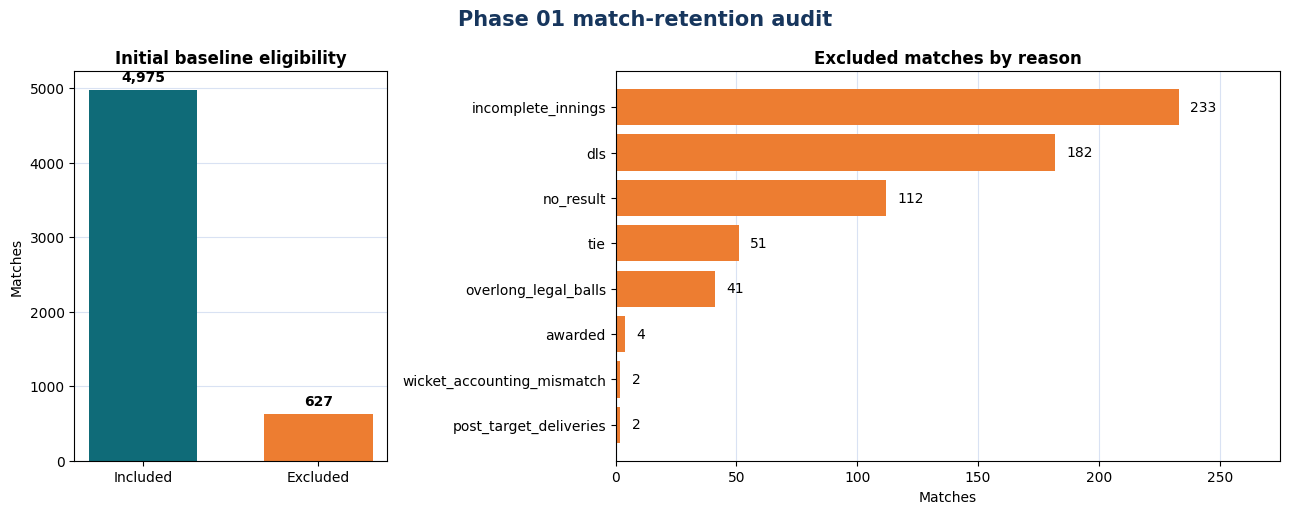

In [6]:
import matplotlib.pyplot as plt

NAVY = '#17365D'
TEAL = '#0F6B78'
ORANGE = '#ED7D31'
LIGHT_GRID = '#D9E2F3'

eligibility_counts = match_status['exclusion_reason'].value_counts()
included_count = int(eligibility_counts.get('included', 0))
excluded_count = int(len(match_status) - included_count)
detail_counts = eligibility_counts.drop(labels='included', errors='ignore').sort_values()

fig, axes = plt.subplots(
    1, 2, figsize=(13, 5.2),
    gridspec_kw={'width_ratios': [0.8, 1.7]},
)

overall_labels = ['Included', 'Excluded']
overall_values = [included_count, excluded_count]
bars = axes[0].bar(overall_labels, overall_values, color=[TEAL, ORANGE], width=0.62)
axes[0].set_title('Initial baseline eligibility', fontweight='bold')
axes[0].set_ylabel('Matches')
axes[0].grid(axis='y', color=LIGHT_GRID, linewidth=0.8)
axes[0].set_axisbelow(True)
for bar, value in zip(bars, overall_values, strict=True):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + max(overall_values) * 0.015,
        f'{value:,}', ha='center', va='bottom', fontweight='bold',
    )

detail_bars = axes[1].barh(detail_counts.index, detail_counts.values, color=ORANGE)
axes[1].set_title('Excluded matches by reason', fontweight='bold')
axes[1].set_xlabel('Matches')
axes[1].grid(axis='x', color=LIGHT_GRID, linewidth=0.8)
axes[1].set_axisbelow(True)
for bar, value in zip(detail_bars, detail_counts.values, strict=True):
    axes[1].text(
        value + max(detail_counts.values) * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{int(value):,}', va='center',
    )
axes[1].set_xlim(0, max(detail_counts.values) * 1.18)

fig.suptitle('Phase 01 match-retention audit', fontsize=15, fontweight='bold', color=NAVY)
fig.tight_layout()
plt.show()

## 5. Build and serialize the cleaned event table

This output preserves the raw event fields required for later player-history construction, audit, and NWC attribution. It intentionally does not calculate chase, rolling, or model features.

In [7]:
included_match_ids = match_status.loc[
    match_status['exclusion_reason'].eq('included'), 'match_id'
]
cleaned = events.loc[events['match_id'].isin(included_match_ids)].copy()

if TEAM_SCOPE == 'legacy_top_11':
    cleaned = cleaned.loc[
        cleaned['batting_team'].isin(LEGACY_TOP_11)
        & cleaned['bowling_team'].isin(LEGACY_TOP_11)
    ].copy()
elif TEAM_SCOPE != 'all_teams':
    raise ValueError("team_scope must be 'all_teams' or 'legacy_top_11'")

cleaned['match_innings'] = cleaned['innings_segment'].astype('int8')
cleaned = cleaned.drop(columns=['first_innings_score_audit', 'target_runs_audit'])
cleaned = cleaned.sort_values('source_row', kind='stable').reset_index(drop=True)

assert cleaned.groupby('match_id')['match_innings'].nunique().eq(2).all()
assert cleaned.groupby('match_id')['source_row'].apply(lambda s: s.is_monotonic_increasing).all()
assert not cleaned['match_id'].isin(score_mismatch_match_ids | wicket_mismatch_match_ids).any()
assert not cleaned['match_id'].isin(incomplete_match_ids).any()
assert not cleaned['match_id'].isin(post_target_delivery_match_ids).any()
assert not cleaned['match_id'].isin(result_target_inconsistent_ids).any()

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
CLEANED_PATH.parent.mkdir(parents=True, exist_ok=True)
cleaned.to_csv(CLEANED_PATH, index=False, compression='gzip')

with gzip.open(CLEANED_PATH, 'rt', newline='') as handle:
    reader = csv.reader(handle)
    serialized_header = next(reader)
    serialized_rows = sum(1 for _ in reader)
assert len(serialized_header) == len(set(serialized_header)), 'Duplicate serialized columns'
assert serialized_rows == len(cleaned), 'Serialized row count mismatch'

print(f'Cleaned event table: {CLEANED_PATH.relative_to(PROJECT_ROOT)}')
print(f'Rows serialized: {serialized_rows:,}')

Cleaned event table: data/interim/phase_01_cleaned_deliveries.csv.gz
Rows serialized: 1,156,215


## 6. Save the audit record

The compact JSON report is version-controlled; raw and cleaned delivery tables remain outside normal Git.

In [8]:
eligible_gender_matches = (
    cleaned[['match_id', 'gender']].drop_duplicates()['gender'].value_counts().sort_index()
)
audit_report = {
    'report_version': 2,
    'source': {
        'matches_rows': int(len(matches)),
        'delivery_rows': int(len(deliveries)),
        'matches_with_deliveries': int(deliveries['match_id'].nunique()),
        'delivery_date_null_rows': int(deliveries['date'].isna().sum()),
        'match_date_min': matches['date'].min().date().isoformat(),
        'match_date_max': matches['date'].max().date().isoformat(),
    },
    'join': {
        'unmatched_delivery_rows': int(events['match_date'].isna().sum()),
        'matches_without_deliveries': int((~matches['match_id'].isin(deliveries['match_id'])).sum()),
    },
    'quality_checks': {
        'runs_total_identity_mismatch_rows': int(
            events['runs_total'].ne(events['runs_batter'] + events['runs_extras']).sum()
        ),
        'wicket_flag_player_out_mismatch_rows': int(
            events['is_wicket_bool'].ne(events['player_out'].notna()).sum()
        ),
        'cumulative_score_mismatch_rows': int(score_accounting_mismatch.sum()),
        'cumulative_wicket_mismatch_rows': int(wicket_accounting_mismatch.sum()),
        'duplicate_displayed_coordinate_rows': int(duplicate_coordinate_rows),
        'overlong_legal_ball_matches': int(len(overlong_match_ids)),
        'two_innings_incomplete_terminal_matches': int(len(incomplete_match_ids)),
        'post_target_delivery_matches': int(len(post_target_delivery_match_ids)),
        'result_target_inconsistent_matches': int(len(result_target_inconsistent_ids)),
    },
    'innings_segments_per_match': {
        str(k): int(v) for k, v in segments_per_match.value_counts().sort_index().items()
    },
    'exclusions': {str(k): int(v) for k, v in exclusion_counts.items()},
    'baseline_eligible_matches': int(cleaned['match_id'].nunique()),
    'baseline_delivery_rows': int(len(cleaned)),
    'source_gender_matches': {
        str(k): int(v) for k, v in matches['gender'].value_counts().sort_index().items()
    },
    'eligible_gender_matches': {str(k): int(v) for k, v in eligible_gender_matches.items()},
    'cleaned_table': {
        'path': str(CLEANED_PATH.relative_to(PROJECT_ROOT)),
        'rows': int(len(cleaned)),
        'columns': int(len(cleaned.columns)),
    },
    'population': {'team_scope': TEAM_SCOPE},
}

assert audit_report['join']['unmatched_delivery_rows'] == 0
assert audit_report['quality_checks']['runs_total_identity_mismatch_rows'] == 0
assert audit_report['quality_checks']['wicket_flag_player_out_mismatch_rows'] == 0
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
REPORT_PATH.write_text(json.dumps(audit_report, indent=2, sort_keys=True) + '\n')

display(pd.DataFrame([
    {'metric': 'eligible matches', 'value': cleaned['match_id'].nunique()},
    {'metric': 'cleaned delivery rows', 'value': len(cleaned)},
    {'metric': 'cleaned columns', 'value': len(cleaned.columns)},
]))
print(f'Audit metrics: {REPORT_PATH.relative_to(PROJECT_ROOT)}')

,metric,value
0,eligible matches,4975
1,cleaned delivery rows,1156215
2,cleaned columns,40


Audit metrics: reports/metrics/phase_01_raw_data_audit.json


## Phase-01 conclusion

The project now has one audited, source-ordered event table containing only the initial standard 120-ball binary baseline. Phase 02 must read this serialized table rather than reimplementing ingestion and eligibility logic.